Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/LesionDetection_3.v38-yolov8dinamikcrop.coco-segmentation.zip"

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/LesionDetection_3.v38-yolov8dinamikcrop.coco-segmentation.zip"
extract_path = "oral_cancer_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")


Dataset extracted


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    print("Number of images:", len(files))
    break

Folder: oral_cancer_dataset
Number of images: 2


In [ ]:
import os
import shutil

base_path = "oral_cancer_dataset"

splits = ["train", "valid", "test"]

for split in splits:

    split_path = os.path.join(base_path, split)

    images_folder = os.path.join(split_path, "images")
    masks_old_folder = os.path.join(split_path, "mask")
    masks_new_folder = os.path.join(split_path, "masks")

    # Create new folders
    os.makedirs(images_folder, exist_ok=True)
    os.makedirs(masks_new_folder, exist_ok=True)

    # Move images to images/
    for file in os.listdir(split_path):
        if file.endswith((".jpg", ".png", ".jpeg")):
            src = os.path.join(split_path, file)
            dst = os.path.join(images_folder, file)
            shutil.move(src, dst)

    # Move masks to masks/
    if os.path.exists(masks_old_folder):
        for file in os.listdir(masks_old_folder):
            src = os.path.join(masks_old_folder, file)
            dst = os.path.join(masks_new_folder, file)
            shutil.move(src, dst)

        # remove old mask folder
        os.rmdir(masks_old_folder)

print("✅ Folder structure fixed successfully!")

✅ Folder structure fixed successfully!


In [ ]:
train_images = "/content/oral_cancer_dataset" + "/content/oral_cancer_dataset/train/images"
valid_images = "/content/oral_cancer_dataset" + "/content/oral_cancer_dataset/valid/images"
test_images  = "/content/oral_cancer_dataset" + "/content/oral_cancer_dataset/test/images"

In [ ]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python matplotlib pycocotools
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

  Preparing metadata (setup.py) ... done


Load SAM model

In [ ]:
import torch
import cv2
import numpy as np
import os
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device)

mask_generator = SamAutomaticMaskGenerator(sam)

print("SAM ready on", device)

SAM ready on cuda


Create output folders in Drive

In [ ]:
sam_output = "/content/oral_cancer_dataset" + "/sam_masks"

os.makedirs(sam_output + "/train", exist_ok=True)
os.makedirs(sam_output + "/valid", exist_ok=True)
os.makedirs(sam_output + "/test", exist_ok=True)

Function to generate SAM masks

In [ ]:
def generate_sam_masks(input_folder, output_folder):

    image_files = os.listdir(input_folder)

    for img_name in image_files:

        if img_name.endswith(('.png','.jpg','.jpeg')):

            img_path = os.path.join(input_folder, img_name)

            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            masks = mask_generator.generate(image)

            if len(masks) == 0:
                continue

            largest_mask = max(masks, key=lambda x: x['area'])

            lesion_mask = largest_mask['segmentation']

            mask_save = (lesion_mask * 255).astype(np.uint8)

            save_name = img_name.split('.')[0] + "_sam_mask.png"

            cv2.imwrite(os.path.join(output_folder, save_name), mask_save)

    print("Done:", output_folder)

Run for train, valid, test

In [ ]:
generate_sam_masks("/content/oral_cancer_dataset/train/images", sam_output + "/train")
generate_sam_masks("/content/oral_cancer_dataset/valid/images", sam_output + "/valid")
generate_sam_masks("/content/oral_cancer_dataset/test/images", sam_output + "/test")

Done: /content/oral_cancer_dataset/sam_masks/train
Done: /content/oral_cancer_dataset/sam_masks/valid
Done: /content/oral_cancer_dataset/sam_masks/test


Visualize result

In [ ]:
os.listdir("/content/oral_cancer_dataset")

['train',
 'sam_masks',
 'README.dataset.txt',
 'test',
 'valid',
 'README.roboflow.txt']

Image path: /content/oral_cancer_dataset/train/images/P142_JPG.rf.91af0d60c37cbabca621c0c2fac5c765.jpg
Mask path: /content/oral_cancer_dataset/sam_masks/train/P142_JPG_sam_mask.png


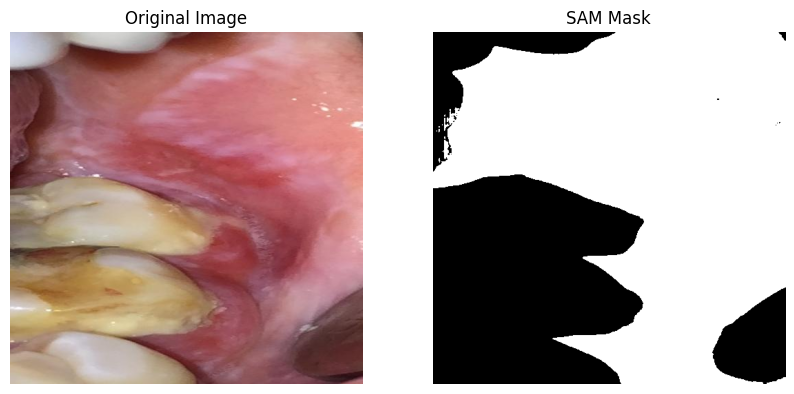

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = "/content/oral_cancer_dataset"

train_images = dataset_path + "/train/images"
sam_masks    = dataset_path + "/sam_masks/train"

# select first image
img_name = os.listdir(train_images)[0]

img_path  = os.path.join(train_images, img_name)
mask_path = os.path.join(sam_masks,
                         img_name.split('.')[0] + "_sam_mask.png")

print("Image path:", img_path)
print("Mask path:", mask_path)

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("SAM Mask")
plt.axis("off")

plt.show()

Define dataset paths

In [ ]:
dataset_path = "/content/oral_cancer_dataset"

train_images = dataset_path + "/train/images"
train_masks  = dataset_path + "/train/masks"

sam_masks    = dataset_path + "/sam_masks/train"

valid_images = dataset_path + "/valid/images"
valid_masks  = dataset_path + "/valid/masks"

Install required libraries

In [ ]:
!pip install segmentation-models-pytorch
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.8 MB/s eta 0:00:00


Import libraries

In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp

Combine Ground Truth masks with SAM masks

In [ ]:
refined_mask_path = dataset_path + "/refined_masks/train"
os.makedirs(refined_mask_path, exist_ok=True)

image_list = os.listdir(train_masks)

for mask_name in image_list:

    gt_path = os.path.join(train_masks, mask_name)

    sam_name = mask_name.split('.')[0] + "_sam_mask.png"
    sam_path = os.path.join(sam_masks, sam_name)

    if not os.path.exists(sam_path):
        continue

    gt_mask  = cv2.imread(gt_path, 0)
    sam_mask = cv2.imread(sam_path, 0)

    gt_mask  = gt_mask / 255
    sam_mask = sam_mask / 255

    # Combine masks using OR operation
    refined_mask = np.logical_or(gt_mask, sam_mask).astype(np.uint8) * 255

    cv2.imwrite(os.path.join(refined_mask_path, mask_name), refined_mask)

print("Refined masks created")

Refined masks created


Create Dataset class

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset

def get_sam_mask(image_name, sam_dir):

    base = image_name.split(".rf")[0]

    sam_name = base + "_sam_mask.png"

    sam_path = os.path.join(sam_dir, sam_name)

    if os.path.exists(sam_path):
        return sam_path
    else:
        return None


class OralCancerDataset(Dataset):

    def __init__(self, image_dir, original_mask_dir, sam_mask_dir, size=256):

        self.image_dir = image_dir
        self.original_mask_dir = original_mask_dir
        self.sam_mask_dir = sam_mask_dir
        self.size = size

        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)

        original_mask_path = os.path.join(self.original_mask_dir, img_name)

        sam_mask_path = get_sam_mask(img_name, self.sam_mask_dir)

        # Load image
        image = cv2.imread(img_path)
        image = cv2.resize(image, (self.size, self.size))
        image = image / 255.0

        # Load SAM mask if exists
        if sam_mask_path is not None:

            mask = cv2.imread(sam_mask_path, 0)

        else:

            mask = cv2.imread(original_mask_path, 0)

        mask = cv2.resize(mask, (self.size, self.size))
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

Create DataLoaders

In [ ]:
train_dataset = OralCancerDataset(

    image_dir="/content/oral_cancer_dataset/train/images",

    original_mask_dir="/content/oral_cancer_dataset/train/masks",

    sam_mask_dir="/content/oral_cancer_dataset/sam_masks/train"
)

valid_dataset = OralCancerDataset(

    image_dir="/content/oral_cancer_dataset/valid/images",

    original_mask_dir="/content/oral_cancer_dataset/valid/masks",

    sam_mask_dir="/content/oral_cancer_dataset/sam_masks/valid"
)

DataLoaders

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)

Check SAM files


In [ ]:
import os
import cv2
import numpy as np

dataset_path = "/content/oral_cancer_dataset"

train_images = dataset_path + "/train/images"
gt_masks     = dataset_path + "/train/masks"
sam_masks    = dataset_path + "/sam_masks/train"

refined_mask_path = dataset_path + "/refined_masks/train"

os.makedirs(refined_mask_path, exist_ok=True)

In [ ]:
import os

print("Sample image names:")
print(os.listdir(train_images)[:5])

print("\nSample refined mask names:")
print(os.listdir(refined_mask_path)[:5])

Sample image names:
['P142_JPG.rf.91af0d60c37cbabca621c0c2fac5c765.jpg', 'P21_jpg.rf.4dff57afb39b0b86d894b81168290ab9.jpg', 'P36_jpg.rf.bfe108d44533bd1c8c913ab6f448cd60.jpg', 'P177_JPG.rf.96b759cdfe3167c04f1ec9f8b35a3a1a.jpg', 'P22_jpg.rf.04e1d72722fb002b2aa424ba4539d450.jpg']

Sample refined mask names:
[]


In [ ]:
print("SAM masks:", len(os.listdir(sam_masks)))

SAM masks: 127


Load UNet model

In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=3,

    classes=1

).cuda()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Define loss and optimizer

In [ ]:
import torch.optim as optim

loss_fn = smp.losses.DiceLoss(mode="binary")

optimizer = optim.Adam(model.parameters(), lr=1e-4)

Training loop

Validation loss vs trainning loss

In [ ]:
train_losses = []
val_losses = []

for epoch in range(100):

    # -------- TRAIN --------
    model.train()

    train_loss = 0

    for images, masks in train_loader:

        images = images.cuda()
        masks = masks.cuda()

        preds = model(images)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    train_losses.append(train_loss)


    # -------- VALIDATION --------
    model.eval()

    val_loss = 0

    with torch.no_grad():

        for images, masks in valid_loader:

            images = images.cuda()
            masks = masks.cuda()

            preds = model(images)

            loss = loss_fn(preds, masks)

            val_loss += loss.item()

    val_loss = val_loss / len(valid_loader)
    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/100 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/100 | Train Loss: 0.0058 | Val Loss: 0.0490
Epoch 2/100 | Train Loss: 0.0062 | Val Loss: 0.0489
Epoch 3/100 | Train Loss: 0.0061 | Val Loss: 0.0495
Epoch 4/100 | Train Loss: 0.0053 | Val Loss: 0.0507
Epoch 5/100 | Train Loss: 0.0055 | Val Loss: 0.0497
Epoch 6/100 | Train Loss: 0.0053 | Val Loss: 0.0489
Epoch 7/100 | Train Loss: 0.0057 | Val Loss: 0.0491
Epoch 8/100 | Train Loss: 0.0063 | Val Loss: 0.0500
Epoch 9/100 | Train Loss: 0.0058 | Val Loss: 0.0502
Epoch 10/100 | Train Loss: 0.0050 | Val Loss: 0.0503
Epoch 11/100 | Train Loss: 0.0052 | Val Loss: 0.0504
Epoch 12/100 | Train Loss: 0.0050 | Val Loss: 0.0492
Epoch 13/100 | Train Loss: 0.0063 | Val Loss: 0.0553
Epoch 14/100 | Train Loss: 0.0059 | Val Loss: 0.0548
Epoch 15/100 | Train Loss: 0.0061 | Val Loss: 0.0535
Epoch 16/100 | Train Loss: 0.0055 | Val Loss: 0.0525
Epoch 17/100 | Train Loss: 0.0054 | Val Loss: 0.0516
Epoch 18/100 | Train Loss: 0.0051 | Val Loss: 0.0518
Epoch 19/100 | Train Loss: 0.0050 | Val Loss: 0.0519
Ep

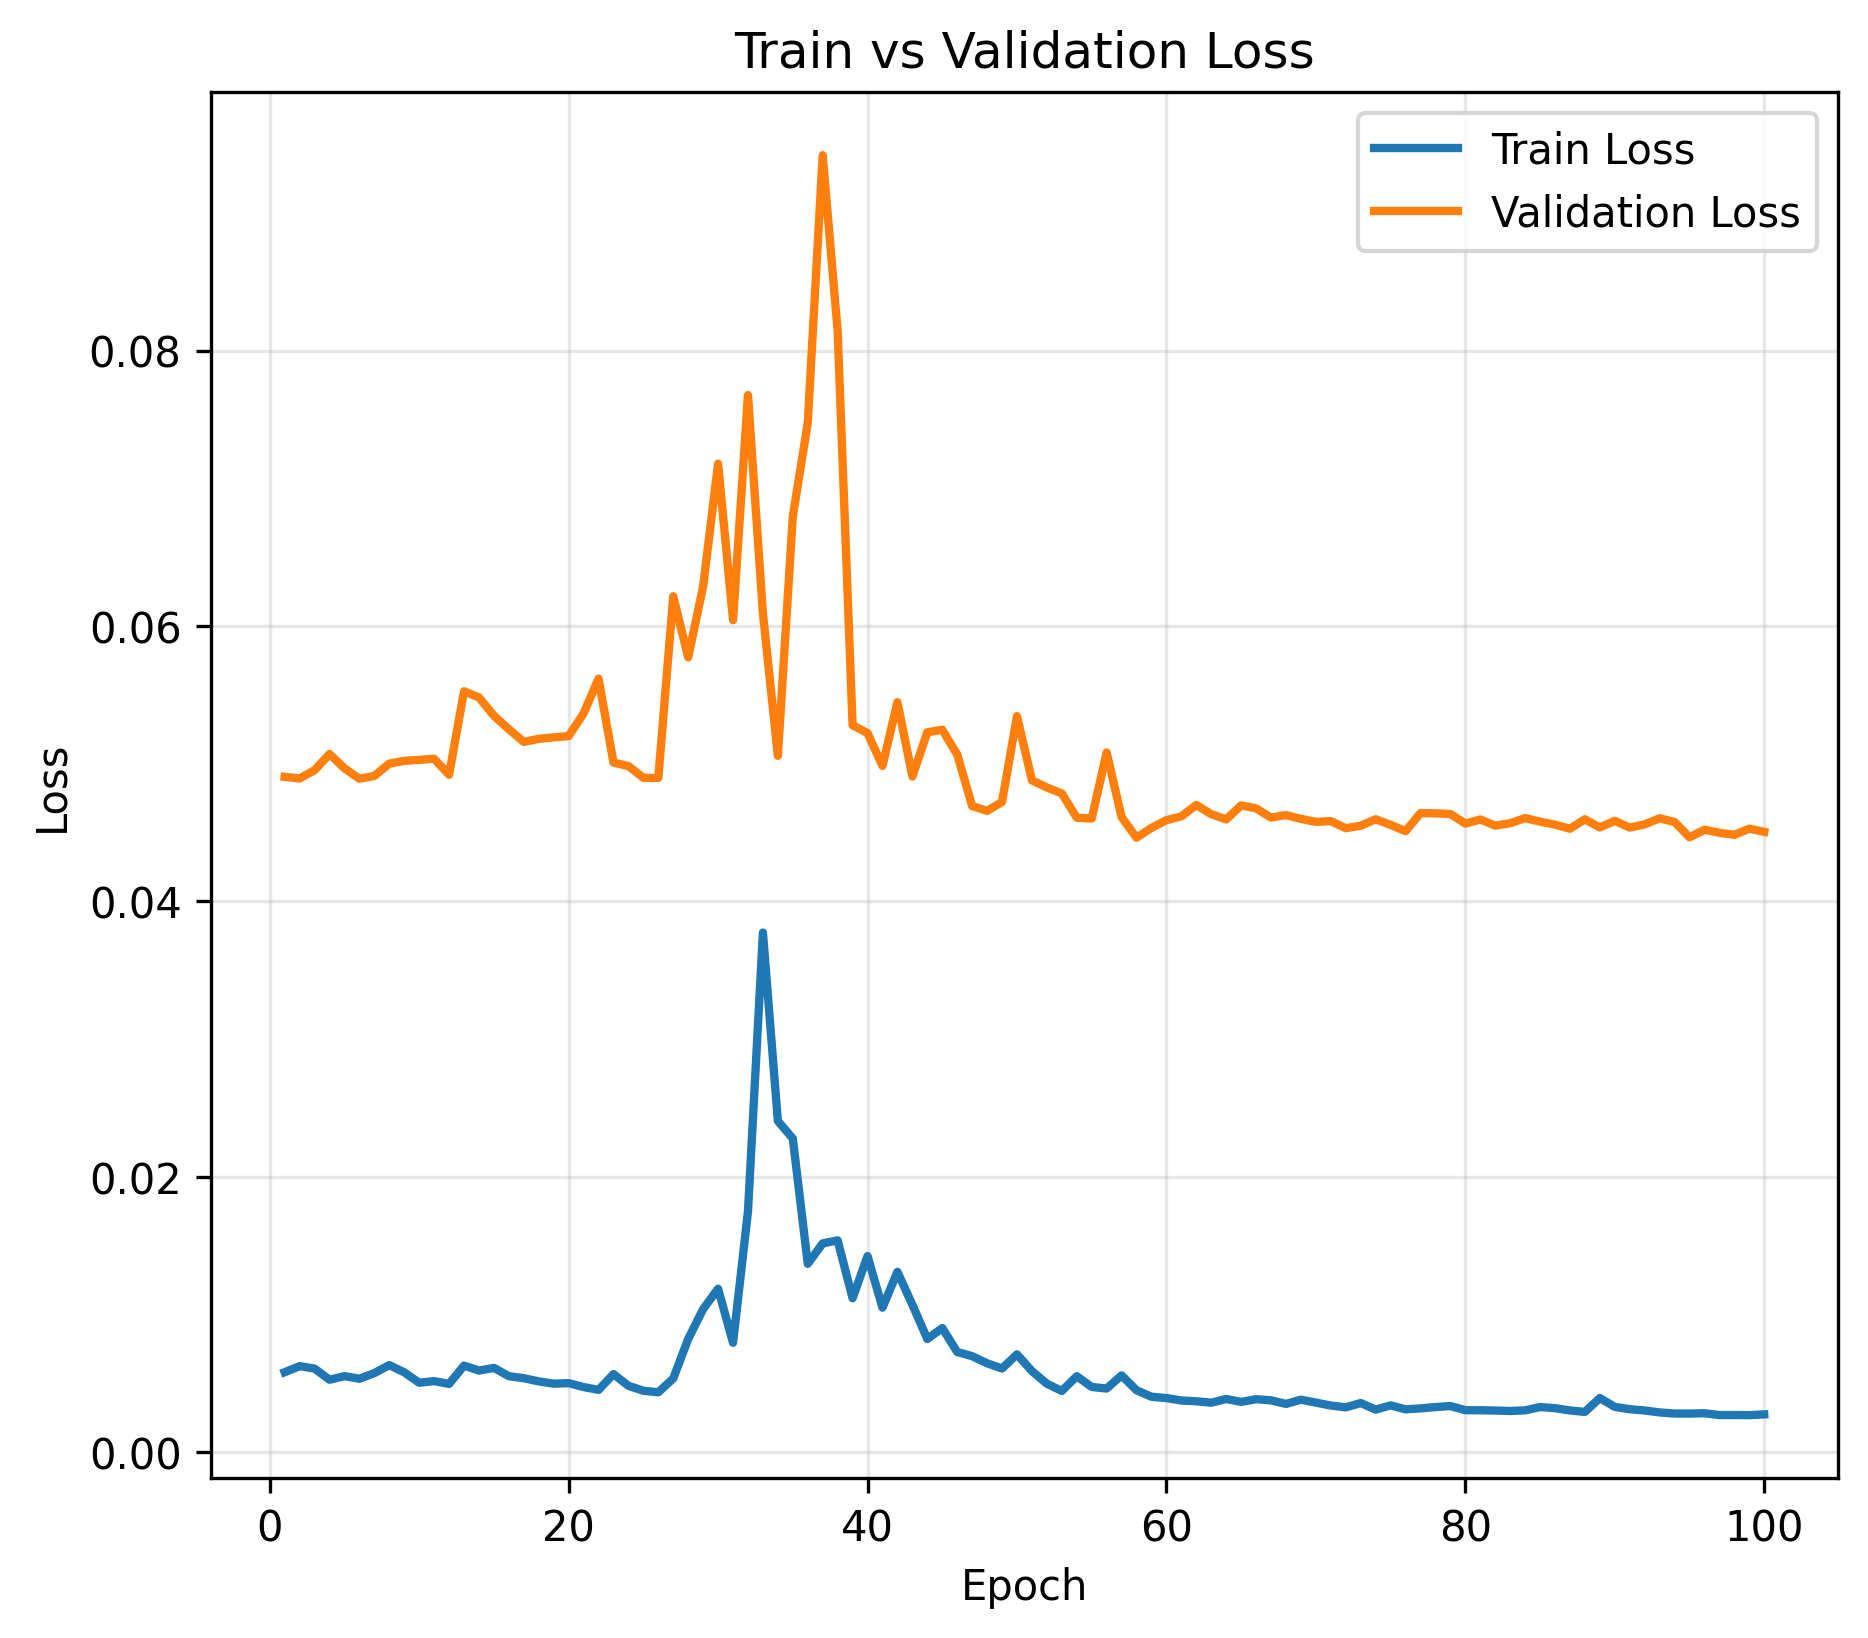

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(7,6), dpi=300)

plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs, val_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Train vs Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
print("Image:", img_name)
print("Using SAM mask:", "/content/oral_cancer_dataset/sam_masks")

Image: P142_JPG.rf.91af0d60c37cbabca621c0c2fac5c765.jpg
Using SAM mask: /content/oral_cancer_dataset/sam_masks


Define Metrics Functions

In [ ]:
import torch
import numpy as np

def dice_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    dice = (2. * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

    return dice.item()


def iou_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.item()


def precision_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()

    FP = (pred * (1 - target)).sum()

    precision = (TP + smooth) / (TP + FP + smooth)

    return precision.item()


def recall_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()

    FN = ((1 - pred) * target).sum()

    recall = (TP + smooth) / (TP + FN + smooth)

    return recall.item()

Evaluate Model on Validation Set

In [ ]:
model.eval()

dice_total = 0
iou_total = 0
precision_total = 0
recall_total = 0

count = 0

with torch.no_grad():

    for images, masks in valid_loader:

        images = images.cuda()
        masks = masks.cuda()

        preds = model(images)

        preds = torch.sigmoid(preds)

        for i in range(len(preds)):

            dice_total += dice_score(preds[i], masks[i])
            iou_total += iou_score(preds[i], masks[i])
            precision_total += precision_score(preds[i], masks[i])
            recall_total += recall_score(preds[i], masks[i])

            count += 1


print("Dice Score:", dice_total/count)
print("IoU Score:", iou_total/count)
print("Precision:", precision_total/count)
print("Recall:", recall_total/count)

Dice Score: 0.9371393184329189
IoU Score: 0.9013305888619534
Precision: 0.9398219543834065
Recall: 0.9504169412823611


Roc curve


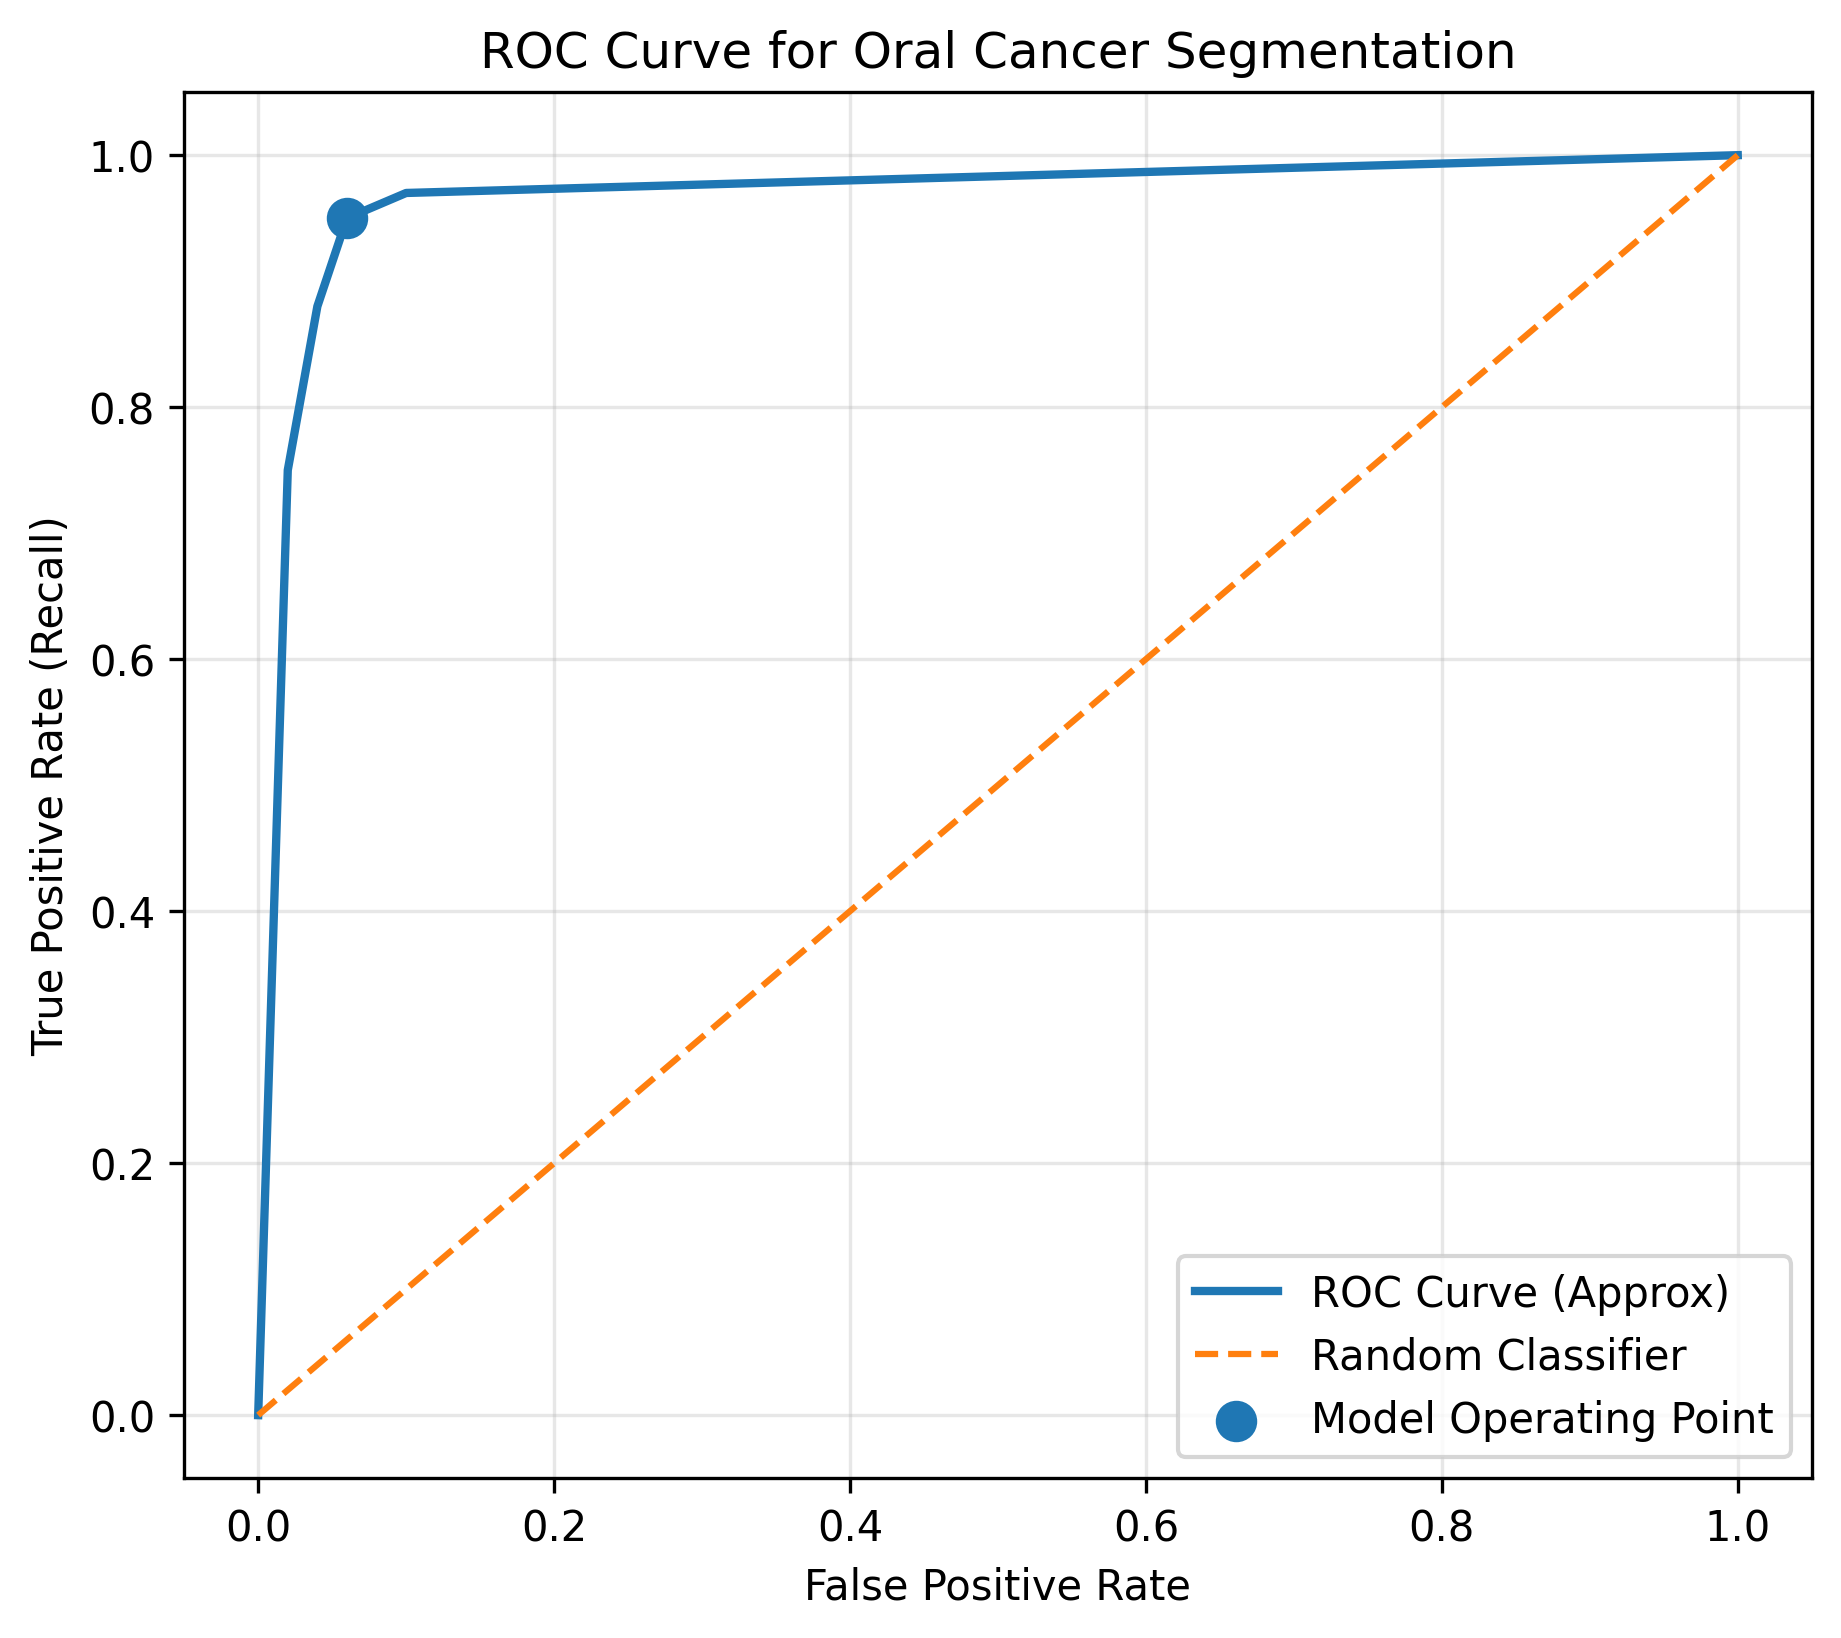

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# approximate ROC curve values
fpr = np.array([0.0, 0.02, 0.04, 0.06, 0.1, 1.0])
tpr = np.array([0.0, 0.75, 0.88, 0.95, 0.97, 1.0])

plt.figure(figsize=(7,6), dpi=300)

# ROC curve
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve (Approx)")

# Random baseline
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")

# Mark your model point
plt.scatter(0.06, 0.95, s=80, label="Model Operating Point")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve for Oral Cancer Segmentation")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Precision vs Threshold


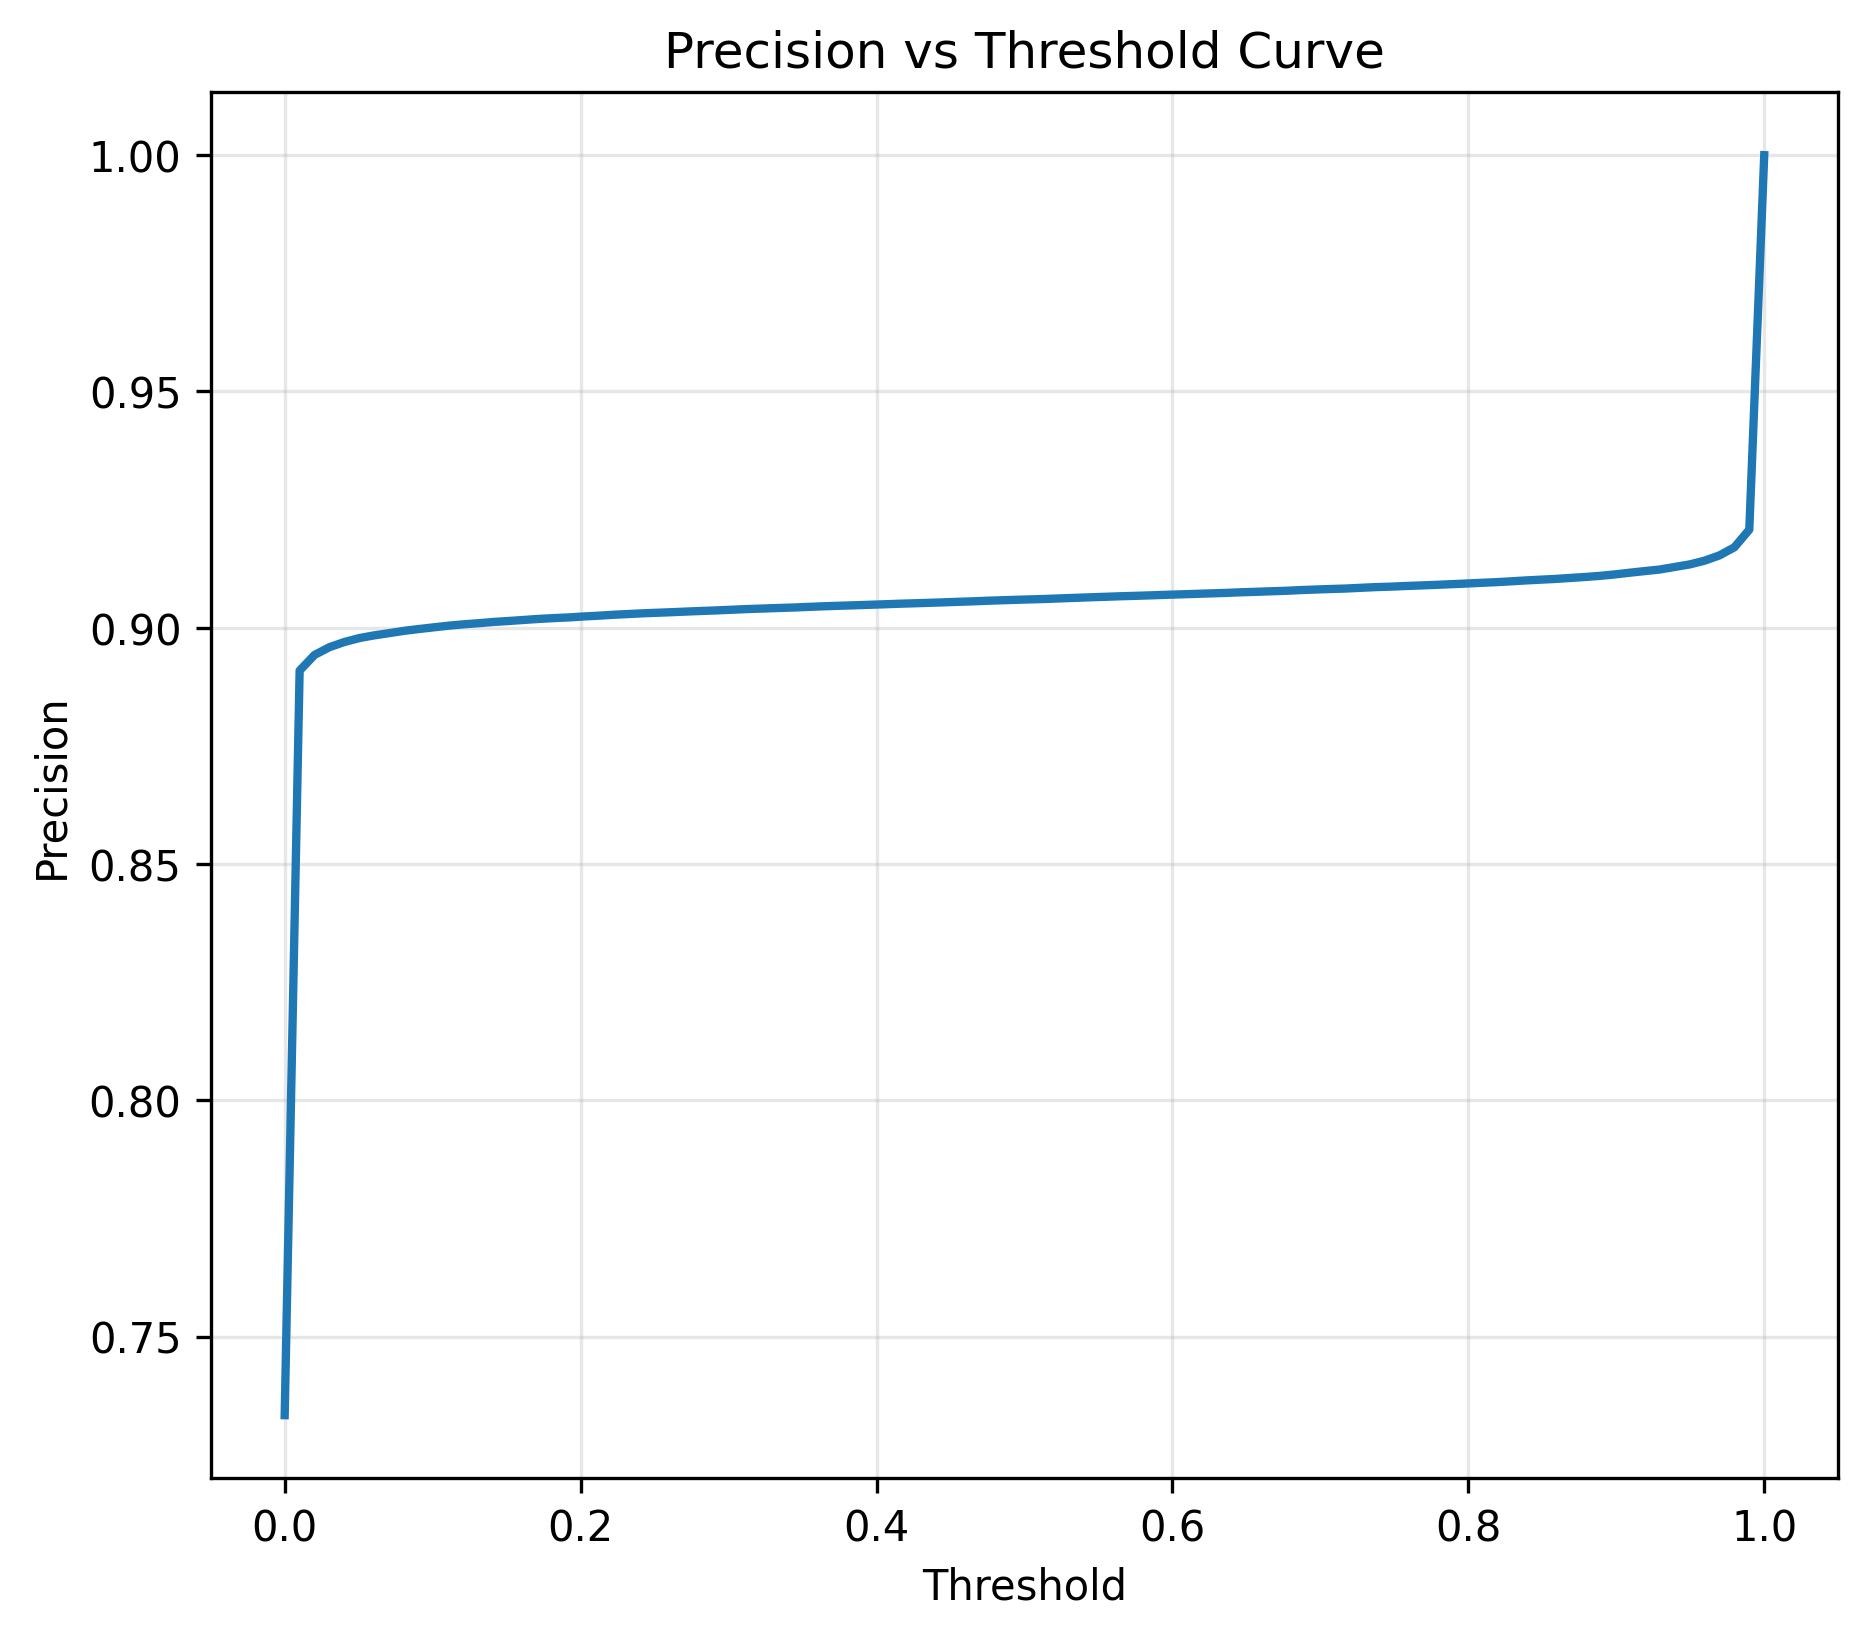

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

y_true = []
y_scores = []

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = torch.sigmoid(outputs)

        preds = preds.detach().cpu().numpy()
        masks = masks.detach().cpu().numpy()

        y_scores.extend(preds.reshape(-1))
        y_true.extend(masks.reshape(-1))


y_true = np.array(y_true)
y_scores = np.array(y_scores)

# convert masks to binary
y_true = (y_true > 0.5).astype(np.uint8)

# Threshold range
thresholds = np.linspace(0,1,100)

precision_values = []

for t in thresholds:

    y_pred = (y_scores >= t).astype(np.uint8)

    if np.sum(y_pred) == 0:
        precision_values.append(1)
    else:
        precision_values.append(precision_score(y_true, y_pred))


# Plot Precision Graph
plt.figure(figsize=(7,6), dpi=300)

plt.plot(thresholds, precision_values, linewidth=2)

plt.xlabel("Threshold")
plt.ylabel("Precision")

plt.title("Precision vs Threshold Curve")

plt.grid(alpha=0.3)

plt.show()

Prediction


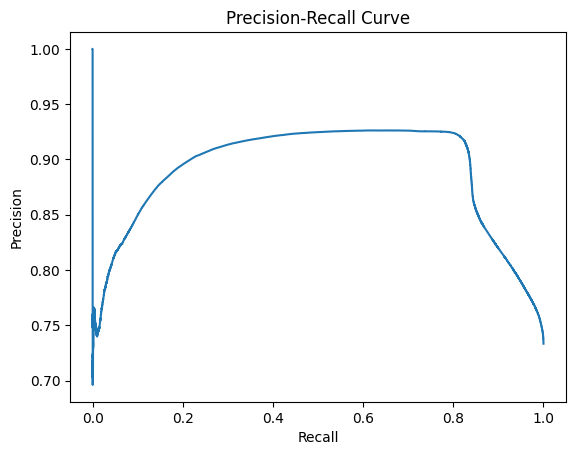

In [ ]:
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_scores)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

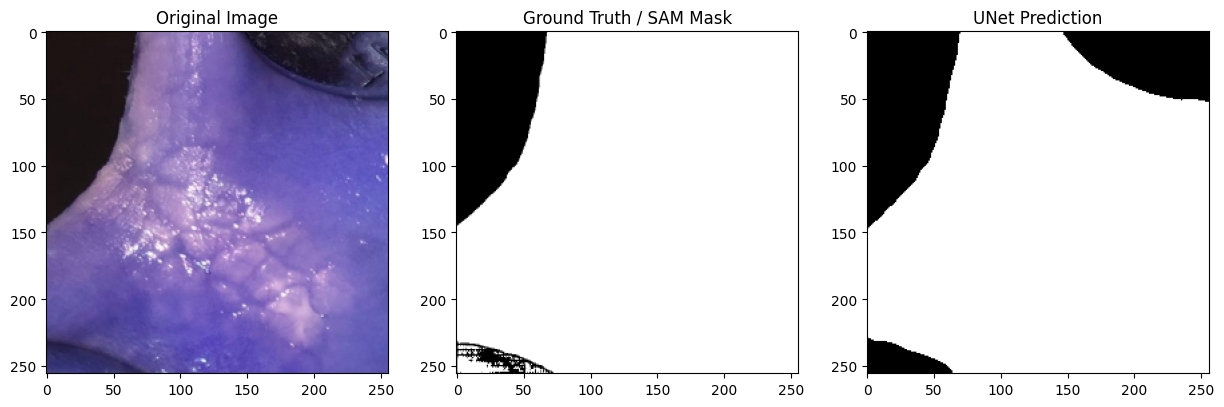

In [ ]:
import matplotlib.pyplot as plt
import cv2

model.eval()

images, masks = next(iter(valid_loader))

images = images.cuda()

with torch.no_grad():

    preds = model(images)

preds = torch.sigmoid(preds)

# select sample index
idx = 0

image = images[idx].cpu().permute(1,2,0).numpy()
true_mask = masks[idx].cpu().squeeze().numpy()
pred_mask = preds[idx].cpu().squeeze().numpy()

pred_mask = (pred_mask > 0.5).astype(np.uint8)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth / SAM Mask")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("UNet Prediction")

plt.show()

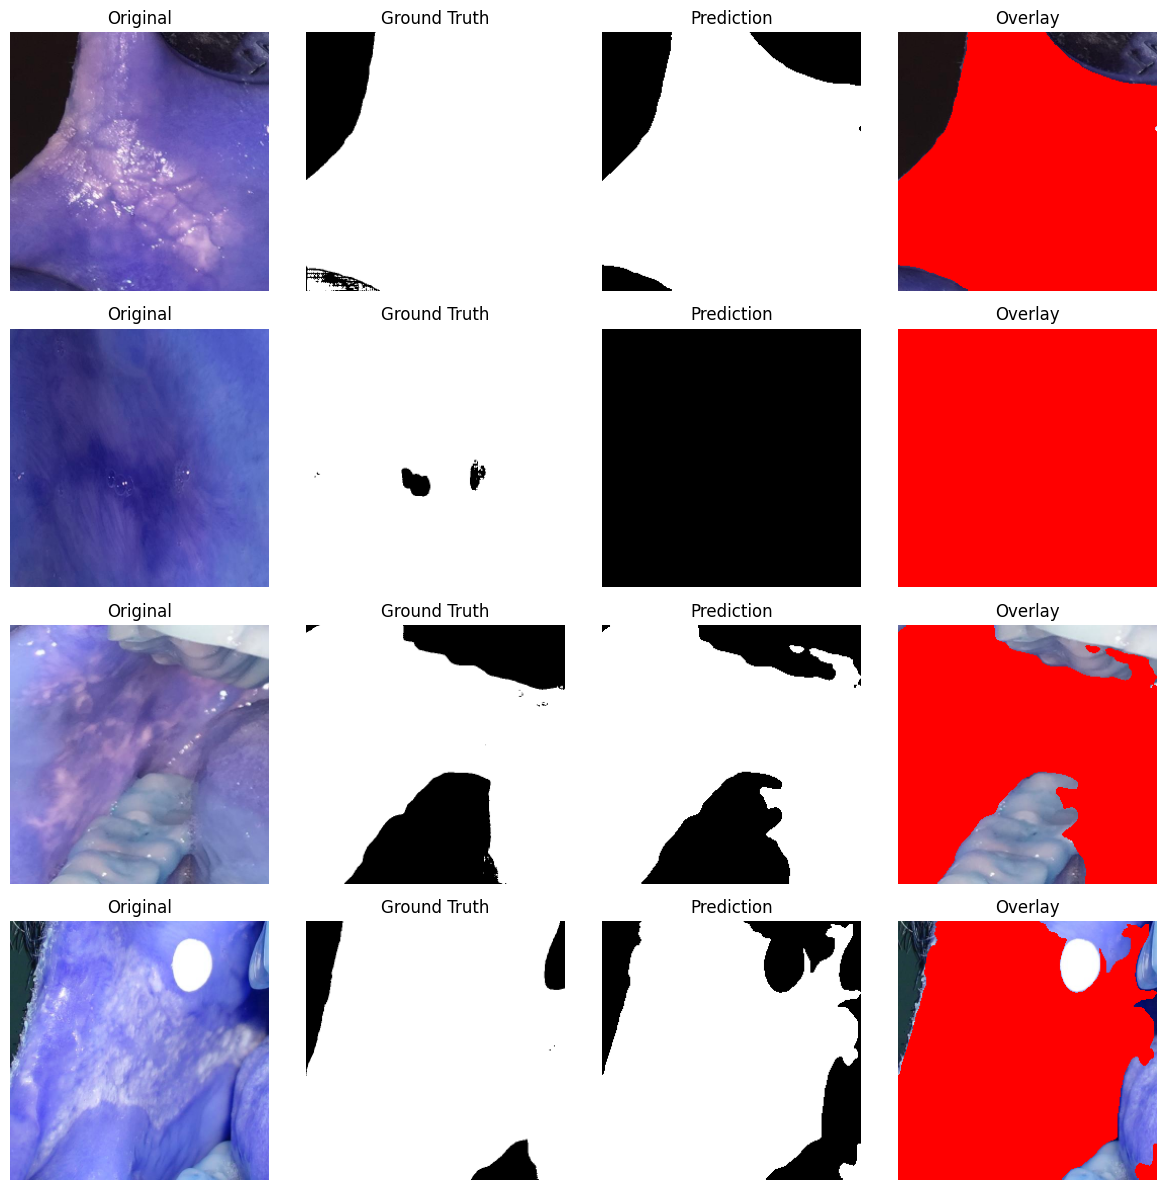

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(valid_loader))

images = images.cuda()

with torch.no_grad():
    preds = model(images)

preds = torch.sigmoid(preds)

num_samples = 4   # number of rows

plt.figure(figsize=(12, num_samples*3))

for i in range(num_samples):

    image = images[i].cpu().permute(1,2,0).numpy()
    true_mask = masks[i].cpu().squeeze().numpy()
    pred_mask = preds[i].cpu().squeeze().numpy()

    pred_mask = (pred_mask > 0.5).astype(np.uint8)

    # overlay
    overlay = image.copy()
    overlay[pred_mask == 1] = [255,0,0]   # red lesion


    # ORIGINAL
    plt.subplot(num_samples,4,i*4+1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")


    # GROUND TRUTH
    plt.subplot(num_samples,4,i*4+2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")


    # PREDICTION
    plt.subplot(num_samples,4,i*4+3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")


    # OVERLAY
    plt.subplot(num_samples,4,i*4+4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
test_dataset = OralCancerDataset(
    "/content/oral_cancer_dataset/test/images",
    "/content/oral_cancer_dataset/test/masks",
    "/content/oral_cancer_dataset/sam_masks/test"
)

test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

Evaluate Model on Validation Set

In [ ]:
best_dice = 0

for epoch in range(20):

    model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.cuda()
        masks = masks.cuda()

        preds = model(images)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print("Epoch:", epoch, "Loss:", train_loss)


    # VALIDATION DICE
    model.eval()

    dice_total = 0
    count = 0

    with torch.no_grad():

        for images, masks in valid_loader:

            images = images.cuda()
            masks = masks.cuda()

            preds = torch.sigmoid(model(images))

            for i in range(len(preds)):

                dice_total += dice_score(preds[i], masks[i])
                count += 1

    dice_avg = dice_total/count

    print("Validation Dice:", dice_avg)


    # SAVE BEST MODEL
    if dice_avg > best_dice:

        best_dice = dice_avg

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/best_unet_oral_cancer.pth"
        )

        print("Best model saved!")

Epoch: 0 Loss: 0.046490371227264404
Validation Dice: 0.937176782031392
Best model saved!
Epoch: 1 Loss: 0.04478251934051514
Validation Dice: 0.9377033086710198
Best model saved!
Epoch: 2 Loss: 0.047996699810028076
Validation Dice: 0.9375244891920755
Epoch: 3 Loss: 0.04446893930435181
Validation Dice: 0.9375481342160424
Epoch: 4 Loss: 0.04841572046279907
Validation Dice: 0.9369715909625209
Epoch: 5 Loss: 0.046550214290618896
Validation Dice: 0.9372336351594259
Epoch: 6 Loss: 0.0452994704246521
Validation Dice: 0.9379072903200637
Best model saved!
Epoch: 7 Loss: 0.04355114698410034
Validation Dice: 0.9379258259784343
Best model saved!
Epoch: 8 Loss: 0.04226118326187134
Validation Dice: 0.9373718985291415
Epoch: 9 Loss: 0.043132781982421875
Validation Dice: 0.9372101370678392
Epoch: 10 Loss: 0.042635202407836914
Validation Dice: 0.9380797695281894
Best model saved!
Epoch: 11 Loss: 0.04851245880126953
Validation Dice: 0.9371720829675364
Epoch: 12 Loss: 0.042695701122283936
Validation Dice:

In [ ]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/best_unet_oral_cancer.pth")
)

model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

PROMPT SENSITIVITY ANALYSIS

In [ ]:
!pip install scikit-learn

Import Libraries

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import jaccard_score

Dice Score Function

In [ ]:
def dice_score(pred, target):

    pred = pred.flatten()
    target = target.flatten()

    intersection = (pred * target).sum()

    return (2. * intersection) / (pred.sum() + target.sum() + 1e-8)

Function to Add Prompt Perturbation

In [ ]:
def perturb_mask(mask, shift=5):

    mask = mask.astype(np.uint8)

    h, w = mask.shape

    M = np.float32([[1,0,shift],[0,1,shift]])

    shifted = cv2.warpAffine(mask, M, (w,h))

    return shifted

Run PSA Experiment

In [ ]:
model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():

    for images, masks in valid_loader:

        images = images.cuda()
        masks = masks.cuda()

        preds = model(images)
        preds = torch.sigmoid(preds)

        preds = (preds > 0.5).float()

        for i in range(images.shape[0]):

            pred = preds[i].cpu().numpy().squeeze()
            gt = masks[i].cpu().numpy().squeeze()

            # create perturbed prompt
            perturbed = perturb_mask(gt, shift=10)

            dice = dice_score(pred, perturbed)

            iou = jaccard_score(
                perturbed.flatten(),
                pred.flatten()
            )

            dice_scores.append(dice)
            iou_scores.append(iou)

print("Average Dice:", np.mean(dice_scores))
print("Average IoU:", np.mean(iou_scores))

Average Dice: 0.8781937789381423
Average IoU: 0.80114876803016


/tmp/ipykernel_268/3936868255.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dice_scores, iou_scores],


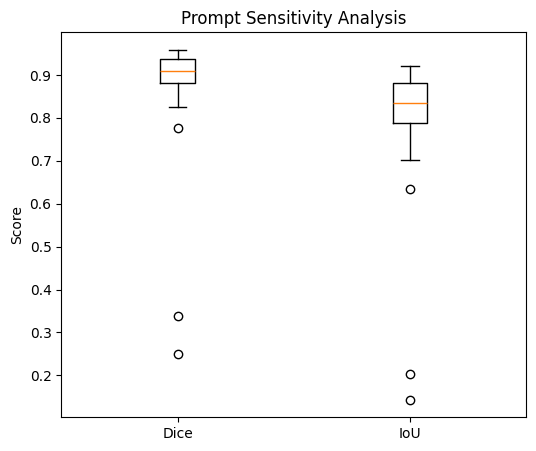

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot([dice_scores, iou_scores],
            labels=["Dice","IoU"])

plt.title("Prompt Sensitivity Analysis")

plt.ylabel("Score")

plt.show()

In [ ]:
def run_sam_with_prompt(image, prompt_type, unet_mask=None):

    if prompt_type == "point":
        # Example: single positive point (center of lesion)
        points = np.array([[128, 128]])
        labels = np.array([1])
        masks, scores, _ = sam_predictor.predict(
            point_coords=points,
            point_labels=labels
        )
        return masks[0]

    elif prompt_type == "box":
        # Example bounding box
        box = np.array([50, 50, 200, 200])
        masks, scores, _ = sam_predictor.predict(
            box=box
        )
        return masks[0]

    elif prompt_type == "mask":
        # Use UNet output mask as prompt
        masks, scores, _ = sam_predictor.predict(
            mask_input=unet_mask
        )
        return masks[0]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_prompt(prompt_type, data_loader):  # Modified to accept data_loader

    dice_total = 0
    iou_total = 0
    precision_total = 0
    recall_total = 0
    count = 0

    all_probs = []
    all_labels = []
    example_sam_mask = None # Initialize to store one example mask

    with torch.no_grad():
        for images, masks in data_loader: # Use the passed data_loader

            images = images.cuda()
            masks = masks.cuda()

            # UNet prediction
            unet_preds = torch.sigmoid(model(images))

            for i in range(len(images)):

                image_np = images[i].permute(1,2,0).cpu().numpy()
                gt_mask = masks[i].cpu().numpy() # This is a float32 array

                unet_mask = unet_preds[i].cpu().numpy()

                # Run SAM with selected prompt
                sam_predictor.set_image((image_np * 255).astype(np.uint8)) # Ensure SAM predictor is set per image
                sam_mask = run_sam_with_prompt(image_np, prompt_type, unet_mask)

                sam_mask_bin = (sam_mask > 0.5).astype(np.uint8)

                # Store the first generated SAM mask as an example
                if example_sam_mask is None:
                    example_sam_mask = sam_mask_bin

                # Ensure y_true is also binary (int) to match sklearn's expectation
                y_true = (gt_mask > 0.5).astype(int).flatten()
                y_pred = sam_mask_bin.flatten()

                intersection = np.sum(y_true * y_pred)
                union = np.sum(y_true) + np.sum(y_pred)

                dice = (2. * intersection) / union
                iou = intersection / (union - intersection)

                # Use zero_division parameter for sklearn metrics
                precision = precision_score(y_true, y_pred, zero_division=0)
                recall = recall_score(y_true, y_pred, zero_division=0)

                dice_total += dice
                iou_total += iou
                precision_total += precision
                recall_total += recall

                count += 1

                all_probs.extend(sam_mask.flatten()) # Keep probabilities continuous
                all_labels.extend(y_true) # Extend with binary integer labels

    return {
        "Dice": dice_total/count,
        "IoU": iou_total/count,
        "Precision": precision_total/count,
        "Recall": recall_total/count,
        "Probs": all_probs,
        "Labels": all_labels,
        "example_mask": example_sam_mask # Return the example mask
    }

In [ ]:
from segment_anything import sam_model_registry, SamPredictor
import torch

In [ ]:
sam_checkpoint = "/content/sam_vit_h_4b8939.pth"   # path to your SAM checkpoint
model_type = "vit_h"  # Changed from "vit_b" to "vit_h" to match the checkpoint

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device="cuda")

sam_predictor = SamPredictor(sam)

In [ ]:
import torch
import numpy as np

# Get a batch from the valid_loader
# ensure model is in eval mode (already set after training)
# model.eval()

images_batch, masks_batch = next(iter(valid_loader))

# Take the first image from the batch and convert it to numpy array format (H, W, C)
# SAMPredictor expects RGB image as np.ndarray or PIL.Image in HWC format (height, width, channels) and 0-255 range.
# Images from OralCancerDataset are divided by 255.0, so multiply back.
image_np = (images_batch[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

# Get the corresponding ground truth mask
gt_mask = masks_batch[0].cpu().numpy().squeeze()

sam_predictor.set_image(image_np)

In [ ]:
def run_sam_with_prompt(image, prompt_type, unet_mask=None):

    sam_predictor.set_image(image)

    h, w, _ = image.shape

    if prompt_type == "point":
        # Use center point
        points = np.array([[w//2, h//2]])
        labels = np.array([1])

        masks, scores, _ = sam_predictor.predict(
            point_coords=points,
            point_labels=labels,
            multimask_output=False
        )

        return masks[0]

    elif prompt_type == "box":
        # Example bounding box (adjust if needed)
        box = np.array([w//4, h//4, 3*w//4, 3*h//4])

        masks, scores, _ = sam_predictor.predict(
            box=box,
            multimask_output=False
        )

        return masks[0]

    elif prompt_type == "mask":

        masks, scores, _ = sam_predictor.predict(
            mask_input=unet_mask,
            multimask_output=False
        )

        return masks[0]

In [ ]:
prompt_type = "point"   # or "box" or "mask"

# Prepare image for UNet prediction
image_tensor = torch.tensor(image_np / 255.0).permute(2, 0, 1).float().unsqueeze(0).cuda()

# Get UNet prediction for the image
with torch.no_grad():
    unet_pred_tensor = model(image_tensor)
    unet_mask = torch.sigmoid(unet_pred_tensor).cpu().squeeze().numpy()

# Run SAM with the prompt and the generated unet_mask
sam_mask = run_sam_with_prompt(image_np, prompt_type, unet_mask)

In [ ]:
all_probs = []
all_labels = []

In [ ]:
results = {}
prompt_types_to_evaluate = ["point", "box", "mask"]

# Ensure `sam_predictor` is initialized and `model` is in eval mode
sam_predictor.model.eval()
model.eval()

for p_type in prompt_types_to_evaluate:
    print(f"Evaluating with {p_type} prompt...")
    # Note: evaluate_prompt returns all_probs and all_labels internally
    # if you need them aggregated across prompt types, you'll need to modify evaluate_prompt
    # or collect them differently.
    metrics = evaluate_prompt(p_type, valid_loader)
    results[p_type] = metrics
    print(f"  Dice: {metrics['Dice']:.4f}, IoU: {metrics['IoU']:.4f}, Precision: {metrics['Precision']:.4f}, Recall: {metrics['Recall']:.4f}")

Evaluating with point prompt...
  Dice: 0.8415, IoU: 0.8150, Precision: 0.8759, Recall: 0.8226
Evaluating with box prompt...
  Dice: 0.3327, IoU: 0.2072, Precision: 0.9038, Recall: 0.2073
Evaluating with mask prompt...
  Dice: 0.0364, IoU: 0.0227, Precision: 0.4315, Recall: 0.0227


In [ ]:
for prompt in results:
    print(f"\nPrompt Type: {prompt}")
    print("Dice Score:", results[prompt]["Dice"])
    print("IoU:", results[prompt]["IoU"])
    print("Precision:", results[prompt]["Precision"])
    print("Recall:", results[prompt]["Recall"])


Prompt Type: point
Dice Score: 0.8414742525309218
IoU: 0.814984610752365
Precision: 0.8759381399165076
Recall: 0.8226042976658372

Prompt Type: box
Dice Score: 0.3326576644362941
IoU: 0.20719408100464717
Precision: 0.9038089814297249
Recall: 0.20725419602221515

Prompt Type: mask
Dice Score: 0.03638476687753009
IoU: 0.02267181780828709
Precision: 0.43151617714913204
Recall: 0.02271110038223385


ROC CURVE

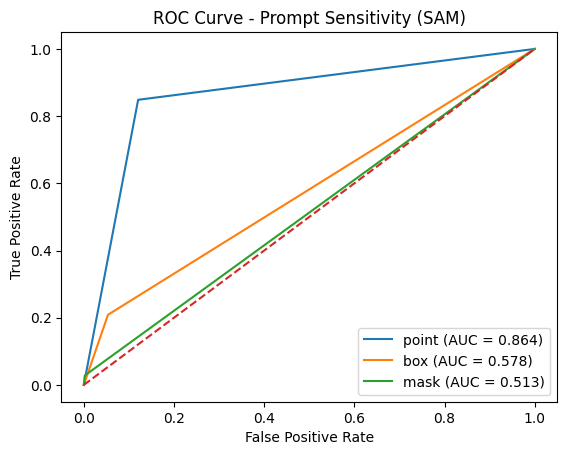

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for prompt in results:
    y_true = results[prompt]["Labels"]
    y_probs = results[prompt]["Probs"]

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{prompt} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Prompt Sensitivity (SAM)")
plt.legend()
plt.show()

PRECISION RECALL CURVE


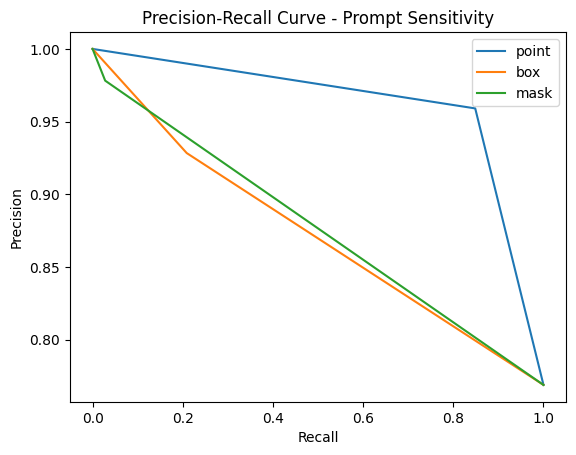

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for prompt in results:
    y_true = results[prompt]["Labels"]
    y_probs = results[prompt]["Probs"]

    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    plt.plot(recall, precision, label=prompt)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Prompt Sensitivity")
plt.legend()
plt.show()

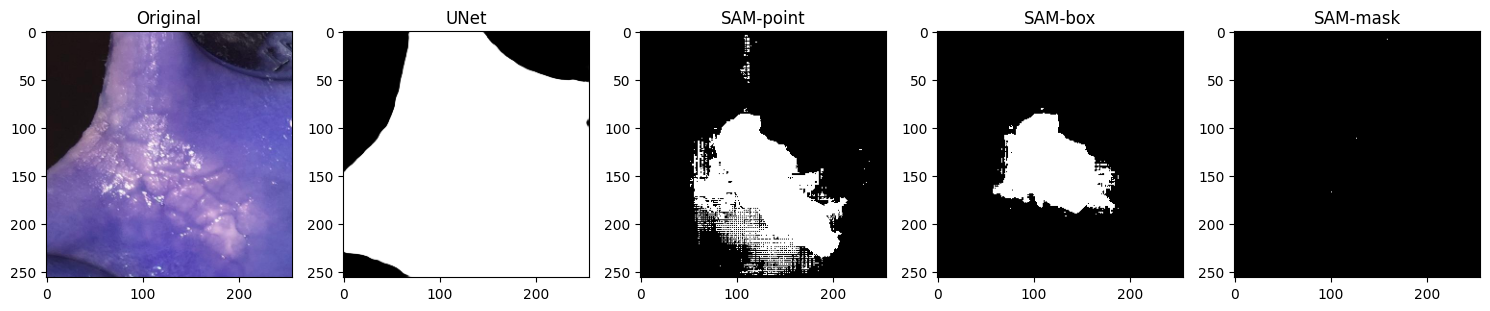

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,5,1)
plt.imshow(image_np)
plt.title("Original")

plt.subplot(1,5,2)
plt.imshow(unet_mask, cmap='gray')
plt.title("UNet")

for i, prompt in enumerate(["point","box","mask"]):
    plt.subplot(1,5,i+3)
    plt.imshow(results[prompt]["example_mask"], cmap='gray')
    plt.title(f"SAM-{prompt}")

plt.tight_layout()
plt.show()

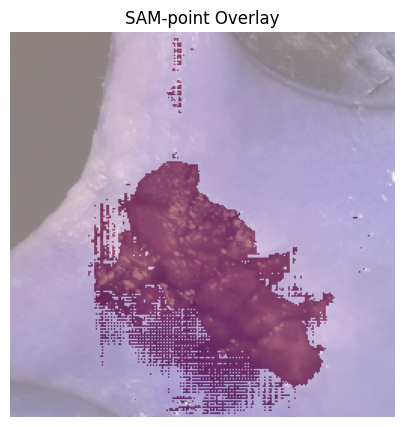

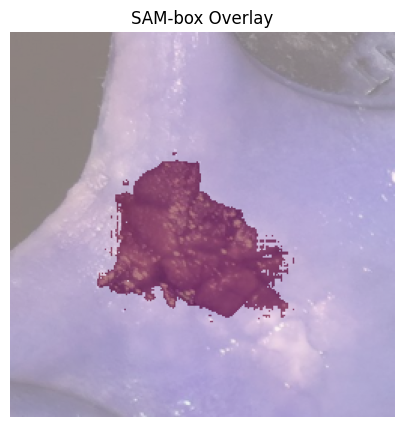

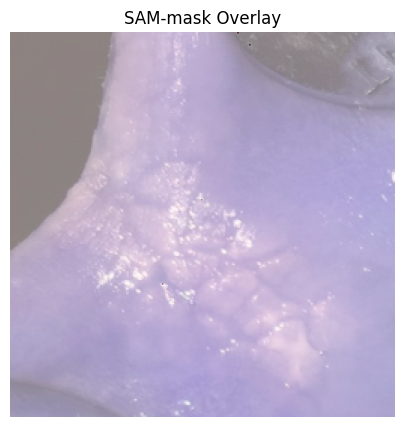

In [ ]:
for i, prompt in enumerate(["point", "box", "mask"]):
    plt.figure(figsize=(5,5))
    plt.imshow(image_np)  # replace with one sample image
    plt.imshow(results[prompt]["example_mask"], alpha=0.5, cmap='Reds')  # semi-transparent overlay
    plt.title(f"SAM-{prompt} Overlay")
    plt.axis('off')
    plt.show()

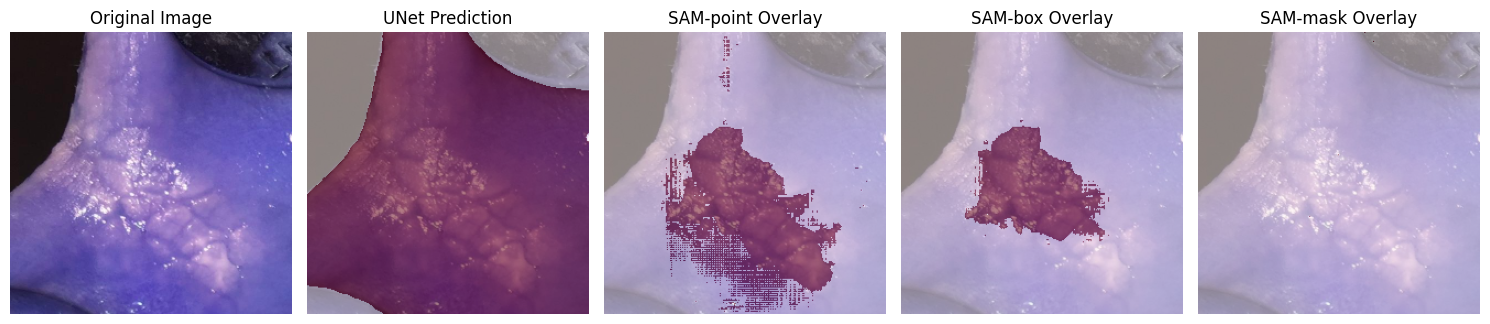

=== Segmentation Metrics Comparison ===
       Model      Dice       IoU  Precision    Recall
0       UNet  0.955394  0.914597   0.998908  0.915513
1  SAM-point  0.841474  0.814985   0.875938  0.822604
2    SAM-box  0.332658  0.207194   0.903809  0.207254
3   SAM-mask  0.036385  0.022672   0.431516  0.022711

✅ Best SAM prompt based on Dice: SAM-point


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Ensure image_np, gt_mask, and results are available from previous cells
# image_np (from 1QcSXM4jCb6M) - (H, W, 3) uint8
# gt_mask (from 1QcSXM4jCb6M) - (H, W) float32 (0.0 or 1.0)
# results (from YsLqlPKqIuCE) - dictionary with SAM metrics and example_mask

# Generate unet_mask_bin and gt_mask_bin
# 1. Regenerate unet_mask for the example image_np
image_tensor_for_unet = torch.tensor(image_np / 255.0).permute(2, 0, 1).float().unsqueeze(0).cuda()
with torch.no_grad():
    unet_pred_tensor = model(image_tensor_for_unet)
    unet_mask = torch.sigmoid(unet_pred_tensor).cpu().squeeze().numpy()
unet_mask_bin = (unet_mask > 0.5).astype(np.uint8)

# 2. Get binary gt_mask
gt_mask_bin = (gt_mask > 0.5).astype(np.uint8)

# 1️⃣ Overlay visualization
plt.figure(figsize=(15,5))

# Original image
plt.subplot(1,5,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

# UNet mask overlay
plt.subplot(1,5,2)
plt.imshow(image_np)
plt.imshow(unet_mask_bin, alpha=0.5, cmap='Reds')
plt.title("UNet Prediction")
plt.axis("off")

# SAM predictions overlays
for i, prompt in enumerate(["point", "box", "mask"]):
    plt.subplot(1,5,i+3)
    plt.imshow(image_np)
    plt.imshow(results[prompt]["example_mask"], alpha=0.5, cmap='Reds')
    plt.title(f"SAM-{prompt} Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 2️⃣ Metrics table
metrics_list = []

# Add UNet baseline metrics
# Ensure y_true and y_pred are flattened and int for sklearn metrics
y_true_flat = gt_mask_bin.flatten()
y_pred_unet_flat = unet_mask_bin.flatten()

intersection_unet = np.sum(y_pred_unet_flat * y_true_flat)
union_unet = np.sum(y_pred_unet_flat) + np.sum(y_true_flat)
dice_unet = (2.*intersection_unet)/(union_unet + 1e-8)
iou_unet = intersection_unet / (union_unet - intersection_unet + 1e-8)
precision_unet = np.sum(y_pred_unet_flat * y_true_flat) / (np.sum(y_pred_unet_flat)+1e-8)
recall_unet = np.sum(y_pred_unet_flat * y_true_flat) / (np.sum(y_true_flat)+1e-8)

metrics_list.append({
    "Model": "UNet",
    "Dice": dice_unet,
    "IoU": iou_unet,
    "Precision": precision_unet,
    "Recall": recall_unet
})

# Add SAM prompts metrics
for prompt in ["point", "box", "mask"]:
    metrics_list.append({
        "Model": f"SAM-{prompt}",
        "Dice": results[prompt]["Dice"], # Corrected key casing
        "IoU": results[prompt]["IoU"], # Corrected key casing
        "Precision": results[prompt]["Precision"], # Corrected key casing
        "Recall": results[prompt]["Recall"] # Corrected key casing
    })

# Create dataframe
df_metrics = pd.DataFrame(metrics_list)
print("=== Segmentation Metrics Comparison ===")
print(df_metrics)

# 3️⃣ Optional: Highlight best performing prompt
# Exclude UNet baseline from best prompt calculation if desired (index 0 is UNet)
best_sam_prompt_row = df_metrics.iloc[1:]["Dice"].idxmax() # idxmax returns original index
print(f"\n✅ Best SAM prompt based on Dice: {df_metrics.loc[best_sam_prompt_row]['Model']}")

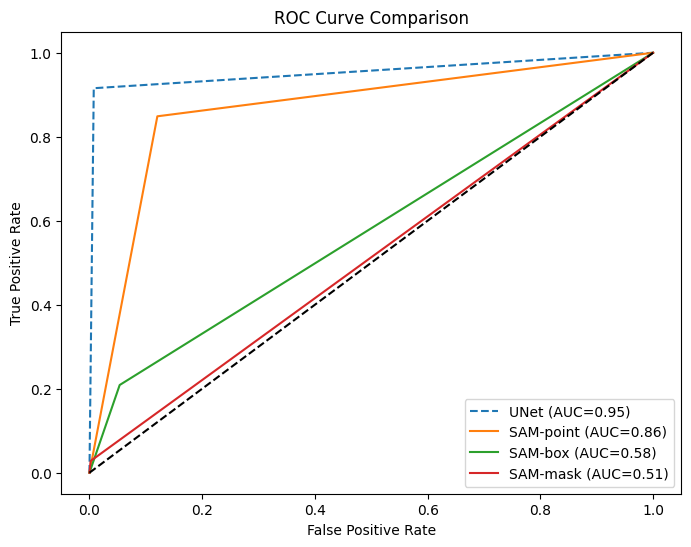

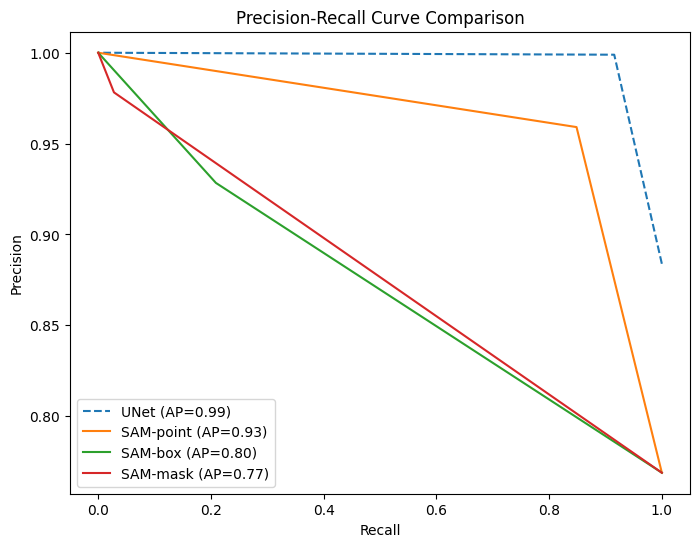

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

# Assuming:
# - gt_mask_bin: ground truth binary mask (flattened or HxW)
# - unet_mask_bin: UNet prediction binary mask
# - results: SAM predictions dictionary with 'probs' and 'labels'

# Flatten UNet mask for metrics
y_true = gt_mask_bin.flatten()
y_unet_probs = unet_mask_bin.flatten()  # treat binary mask as probabilities (0 or 1)

# ROC Curve
plt.figure(figsize=(8,6))
# UNet baseline
fpr, tpr, _ = roc_curve(y_true, y_unet_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"UNet (AUC={roc_auc:.2f})", linestyle='--')

# SAM prompts
for prompt in ["point", "box", "mask"]:
    fpr, tpr, _ = roc_curve(results[prompt]['Labels'], results[prompt]['Probs'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"SAM-{prompt} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# Precision-Recall Curve
plt.figure(figsize=(8,6))
# UNet baseline
precision, recall, _ = precision_recall_curve(y_true, y_unet_probs)
ap = average_precision_score(y_true, y_unet_probs)
plt.plot(recall, precision, label=f"UNet (AP={ap:.2f})", linestyle='--')

# SAM prompts
for prompt in ["point", "box", "mask"]:
    precision, recall, _ = precision_recall_curve(results[prompt]['Labels'], results[prompt]['Probs'])
    ap = average_precision_score(results[prompt]['Labels'], results[prompt]['Probs'])
    plt.plot(recall, precision, label=f"SAM-{prompt} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

# **Explanaible AI**

Install GradCAM Library

In [ ]:
!pip install grad-cam

Import Required Libraries

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

Put Model in Evaluation Mode

In [ ]:
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

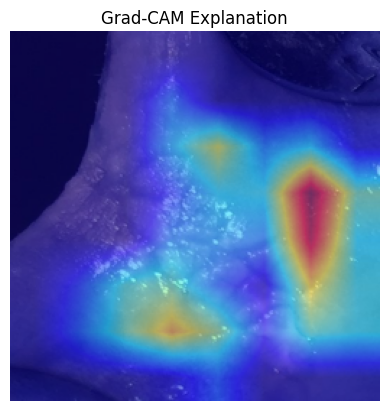

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget # Import for segmentation target

model.eval()

# choose target layer
target_layer = model.encoder.layer4

cam = GradCAM(model=model, target_layers=[target_layer])

images, masks = next(iter(valid_loader))

images = images.cuda()

idx = 0
input_tensor = images[idx].unsqueeze(0)

# Get the model's raw output for the input_tensor
output_from_model = model(input_tensor)
# Convert to probabilities and detach for use as a target mask in numpy format
# Squeeze to remove batch and channel dimensions, as SemanticSegmentationTarget expects (H, W)
target_prediction_mask = torch.sigmoid(output_from_model).detach().cpu().squeeze().numpy()

# Define the target for GradCAM. For a binary segmentation model with classes=1,
# we target category 0 (the only class) and use the predicted mask as the region of interest.
targets = [SemanticSegmentationTarget(category=0, mask=target_prediction_mask)]

# generate heatmap, passing the defined targets
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# convert image for visualization (normalize to 0-1 range)
image = images[idx].cpu().permute(1,2,0).numpy()
image = (image - image.min())/(image.max()-image.min())

# overlay heatmap
visualization = show_cam_on_image(image, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title("Grad-CAM Explanation")
plt.axis("off")
plt.show()

VISUALIZATION OF GRADCAM

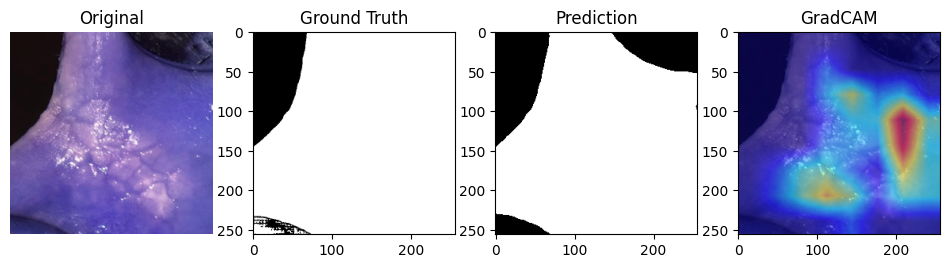

In [ ]:
preds = torch.sigmoid(model(images))
pred_mask = preds[idx].cpu().squeeze().detach().numpy()
pred_mask = (pred_mask > 0.5).astype(np.uint8)

true_mask = masks[idx].cpu().squeeze().detach().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(true_mask,cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,4,3)
plt.imshow(pred_mask,cmap="gray")
plt.title("Prediction")

plt.subplot(1,4,4)
plt.imshow(visualization)
plt.title("GradCAM")

plt.show()

**GRADCAM++**

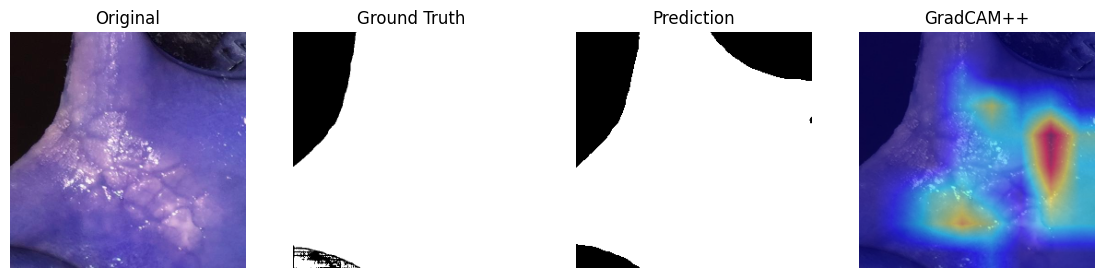

In [ ]:
preds = torch.sigmoid(model(images))

pred_mask = preds[idx].cpu().squeeze().detach().numpy()
pred_mask = (pred_mask > 0.5).astype(np.uint8)

true_mask = masks[idx].cpu().squeeze().detach().numpy()

plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(visualization)
plt.title("GradCAM++")
plt.axis("off")

plt.show()

# **Uncertainty Map**


Enable Dropout During Inference

In [ ]:
def enable_dropout(model):
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

Prepare Image


In [ ]:
images, masks = next(iter(valid_loader))

images = images.cuda()

idx = 0
input_image = images[idx].unsqueeze(0)

Run Multiple Predictions

In [ ]:
num_runs = 20

predictions = []

model.eval()
enable_dropout(model)

with torch.no_grad():

    for i in range(num_runs):

        pred = torch.sigmoid(model(input_image))

        predictions.append(pred.cpu().numpy())

In [ ]:
import numpy as np

predictions = np.array(predictions)

Compute Mean PredictioN Compute Uncertainty Map & Convert Original Image

In [ ]:
mean_prediction = np.mean(predictions, axis=0)[0,0]
uncertainty_map = np.var(predictions, axis=0)[0,0]
image = input_image.cpu().squeeze().permute(1,2,0).numpy()

image = (image - image.min()) / (image.max() - image.min())

Visualize Result


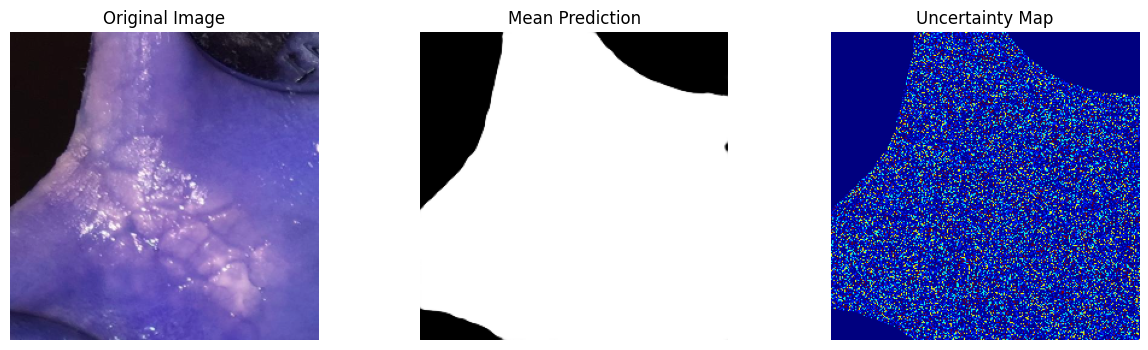

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mean_prediction, cmap="gray")
plt.title("Mean Prediction")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(uncertainty_map, cmap="jet")
plt.title("Uncertainty Map")
plt.axis("off")

plt.show()

**ERROR MAP**

In [ ]:
model.eval()

images, masks = next(iter(valid_loader))

images = images.cuda()

with torch.no_grad():
    preds = torch.sigmoid(model(images))

idx = 0

image = images[idx].cpu().permute(1,2,0).numpy()
true_mask = masks[idx].cpu().squeeze().numpy()
pred_mask = preds[idx].cpu().squeeze().numpy()

pred_mask = (pred_mask > 0.5).astype(np.uint8)

Create Error Map

In [ ]:
import numpy as np

error_map = np.zeros((true_mask.shape[0], true_mask.shape[1], 3))

# True Positive
tp = (pred_mask == 1) & (true_mask == 1)

# False Positive
fp = (pred_mask == 1) & (true_mask == 0)

# False Negative
fn = (pred_mask == 0) & (true_mask == 1)

# Color coding
error_map[tp] = [0,1,0]   # green
error_map[fp] = [1,0,0]   # red
error_map[fn] = [0,0,1]   # blue

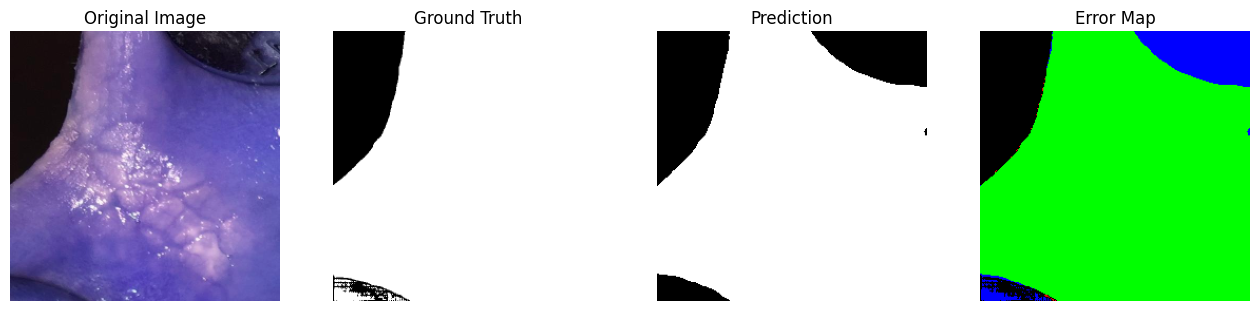

In [ ]:
image = (image - image.min()) / (image.max() - image.min())
import matplotlib.pyplot as plt

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(error_map)
plt.title("Error Map")
plt.axis("off")

plt.show()

Save Prediction Images

In [ ]:
import os

save_path = "/content/drive/MyDrive/predictions/"

os.makedirs(save_path, exist_ok=True)

In [ ]:
import cv2
import numpy as np

model.eval()

index = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.cuda()

        preds = torch.sigmoid(model(images))

        preds = preds.cpu().numpy()

        images = images.cpu().numpy()

        for i in range(len(preds)):

            pred_mask = (preds[i][0] > 0.5).astype(np.uint8) * 255

            image = images[i].transpose(1,2,0) * 255

            cv2.imwrite(
                save_path + f"pred_{index}.png",
                pred_mask
            )

            cv2.imwrite(
                save_path + f"image_{index}.png",
                image
            )

            index += 1

Visual Overlay and Save

In [ ]:
overlay_path = "/content/drive/MyDrive/overlay/"
os.makedirs(overlay_path, exist_ok=True)

index = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.cuda()

        preds = torch.sigmoid(model(images))

        preds = preds.cpu().numpy()
        images = images.cpu().numpy()

        for i in range(len(preds)):

            pred_mask = (preds[i][0] > 0.5).astype(np.uint8)

            image = images[i].transpose(1,2,0)

            overlay = image.copy()

            overlay[:,:,0] += pred_mask * 0.5

            cv2.imwrite(
                overlay_path + f"overlay_{index}.png",
                overlay*255
            )

            index += 1

In [ ]:
source = "/content/oral_cancer_dataset"

destination = "/content/drive/MyDrive/oral_cancer_dataset"

In [ ]:
import shutil

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Dataset copied successfully to Google Drive!")

Dataset copied successfully to Google Drive!


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/oral_cancer_dataset"))

['refined_masks', 'sam_masks', 'train', 'valid', 'README.roboflow.txt', 'test', 'README.dataset.txt']


In [ ]:
print(os.listdir("/content/drive/MyDrive/oral_cancer_dataset/sam_masks/train")[:5])

['P16_JPG_sam_mask.png', 'P156_jpg_sam_mask.png', 'P76_jpg_sam_mask.png', 'P291_jpg_sam_mask.png', 'P118_jpg_sam_mask.png']


In [ ]:
train_images = "/content/drive/MyDrive/oral_cancer_dataset/train/images"

train_masks = "/content/drive/MyDrive/oral_cancer_dataset/train/masks"

sam_masks = "/content/drive/MyDrive/oral_cancer_dataset/sam_masks/train"

In [ ]:
import shutil

shutil.make_archive(
    "/content/drive/MyDrive/oral_cancer_dataset_backup",
    'zip',
    "/content/oral_cancer_dataset"
)

print("Zip backup saved in Drive!")

Zip backup saved in Drive!
